# **Car Fuel Consumption EDA**

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA


## 1. Data Loading


In [2]:
df = pd.read_csv("car_data.csv")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn dtypes:")
print(df.dtypes)


Shape: 550 rows × 12 columns

Column dtypes:
city_mpg             int64
class                  str
combination_mpg      int64
cylinders          float64
displacement       float64
drive                  str
fuel_type              str
highway_mpg          int64
make                   str
model                  str
transmission           str
year                 int64
dtype: object


# **Feature Classification**

## **Quantitative Features**  
*(Numeric features that can be measured or counted)*

**Target (Dependent Feature):**  
- **combination_mpg** – Overall fuel efficiency under mixed driving conditions.

**Numerical Continuous Features:**  
- **city_mpg** – Fuel efficiency during city driving.  
- **highway_mpg** – Fuel efficiency during highway driving.  
- **displacement** – Engine size in liters.

**Numerical Discrete / Ordinal Features:**  
- **cylinders** – Number of engine cylinders (discrete count).  
- **year** – Manufacturing year (ordinal numeric).

---

## **Qualitative Features**  
*(Categorical features describing type or category)*

**Categorical (Nominal) Features:**  
- **class** – Vehicle class (e.g., midsize, SUV, compact).  
- **drive** – Drive type (FWD, RWD, AWD).  
- **fuel_type** – Type of fuel (gasoline, diesel, etc.).  
- **make** – Manufacturer of the vehicle.  
- **model** – Vehicle variant/model.  
- **transmission** – Transmission type (manual or automatic).


# **Classification of Features into 4 levels**
# Measurement Scale Classification



## Nominal

Nominal variables represent categories or labels with no inherent order.  
Arithmetic operations cannot be performed on them.

### Examples:
- class
- drive
- fuel_type
- make
- model
- transmission



## Ordinal

Ordinal variables represent categories with a meaningful order, but the differences between categories are not necessarily equal.

### Examples:
- None in this dataset



## Interval

Interval variables have meaningful order and equal intervals between values, but they do not have a true zero point.  
Ratios between values are not meaningful.

### Examples:
- year



## Ratio

Ratio variables have all the properties of interval variables, with the addition of a true zero point.  
All arithmetic operations are valid, and ratios are meaningful.

### Examples:
- combination_mpg
- city_mpg
- highway_mpg
- displacement
- cylinders

## 2. Initial Inspection


### U.S. EPA fuel economy testing standards
Combination MPG=0.55×City MPG+0.45×Highway MPG

In [3]:

df['combination_mpg'].describe()


count    550.000000
mean      24.069091
std        7.478369
min       14.000000
25%       20.000000
50%       23.000000
75%       27.000000
max      112.000000
Name: combination_mpg, dtype: float64

## 3. Data Wrangling


In [4]:


df = df.drop_duplicates(keep='first')
print(f"After deduplication: {df.shape[0]} rows (removed {550 - df.shape[0]} duplicates)")


After deduplication: 548 rows (removed 2 duplicates)


In [5]:

# Entity cleanup: strip whitespace + lowercase all categoricals ---
cat_raw = df.select_dtypes(include='object').columns.tolist()
for col in cat_raw:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Normalize transmission variants → 'a' / 'm'
entity_map = {'automatic': 'a', 'auto': 'a', 'manual': 'm'}
if 'transmission' in df.columns:
    df['transmission'] = df['transmission'].replace(entity_map)

print("\nUnique values after entity cleanup:")
for col in ['drive', 'fuel_type', 'transmission']:
    if col in df.columns:
        print(f"  {col}: {sorted(df[col].dropna().unique())}")




Unique values after entity cleanup:
  drive: ['4wd', 'awd', 'fwd', 'rwd']
  fuel_type: ['diesel', 'electricity', 'gas']
  transmission: ['a', 'm']


In [6]:
# Missing value audit ---
missing_count = df.isnull().sum()
print("\nMissing values per column:")
print(missing_count[missing_count > 0])
# Impute: numeric → median, categorical → mode
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    mode_val = df[col].mode(dropna=True)
    df[col] = df[col].replace('nan', np.nan).fillna(mode_val.iloc[0] if len(mode_val) else 'unknown')

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")


Missing values per column:
cylinders       2
displacement    2
dtype: int64

Missing values after imputation: 0


In [7]:



#  Create df_filtered: winsorized target (1-99%) for visualisation; 
df_filtered = df.copy()
lb = df_filtered['combination_mpg'].quantile(0.01)
ub = df_filtered['combination_mpg'].quantile(0.99)
df_filtered['combination_mpg'] = df_filtered['combination_mpg'].clip(lb, ub)
analysis_df = df_filtered  

print(f"\ndf (clean): {df.shape}  |  df_filtered / analysis_df (capped target): {df_filtered.shape}")



df (clean): (548, 12)  |  df_filtered / analysis_df (capped target): (548, 12)


## Wrangling Insights

**Initial Dataset Shape:**  
The dataset originally contained **550 rows and 12 columns**.

**Duplicates:**  
2 exact duplicates were removed, leaving **548 clean rows** for analysis.

**Missing Values:**  
- `cylinders` and `displacement` each had **2 missing values (0.36%)**.  
- These were imputed using the **column median** to preserve distribution.

**Categorical Cleanup:**  
- All text columns were **stripped of whitespace** and **converted to lowercase**.  
- The `transmission` column was standardized to `'a'` (automatic) or `'m'` (manual).

**Outlier Treatment:**  
- For EDA visualization, `combination_mpg` was **winsorized at the 1st–99th percentile** (`df_filtered`).  
- The raw dataset (`df`) was kept for modeling to allow **outlier comparisons** and maintain true variance.

## 4. Exploratory Data Analysis
### Distribution & Outliers


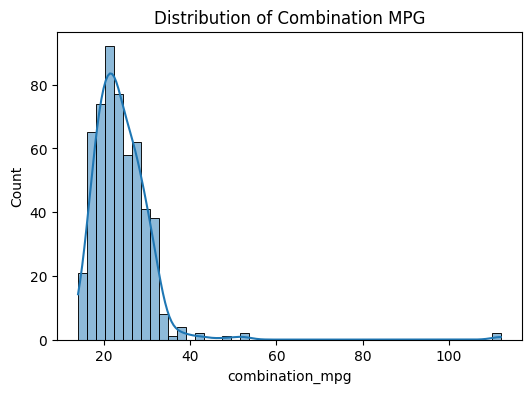

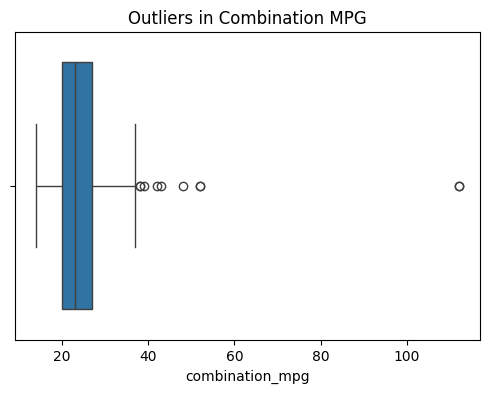

Skewness: 6.276177867004319


In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['combination_mpg'],kde=True)
plt.title("Distribution of Combination MPG")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['combination_mpg'])
plt.title("Outliers in Combination MPG")
plt.show()

print("Skewness:", df['combination_mpg'].skew())


## Outlier detection:

In [9]:
q1=df['combination_mpg'].quantile(0.25)
q3=df['combination_mpg'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
print("Lower bound=",lower_bound)
print("Upper bound=",upper_bound)

outlier=df[(df["combination_mpg"]<lower_bound)|(df["combination_mpg"]>upper_bound)]
print("Number of outlier=",len(outlier))

Lower bound= 9.5
Upper bound= 37.5
Number of outlier= 10


## Outlier treatment

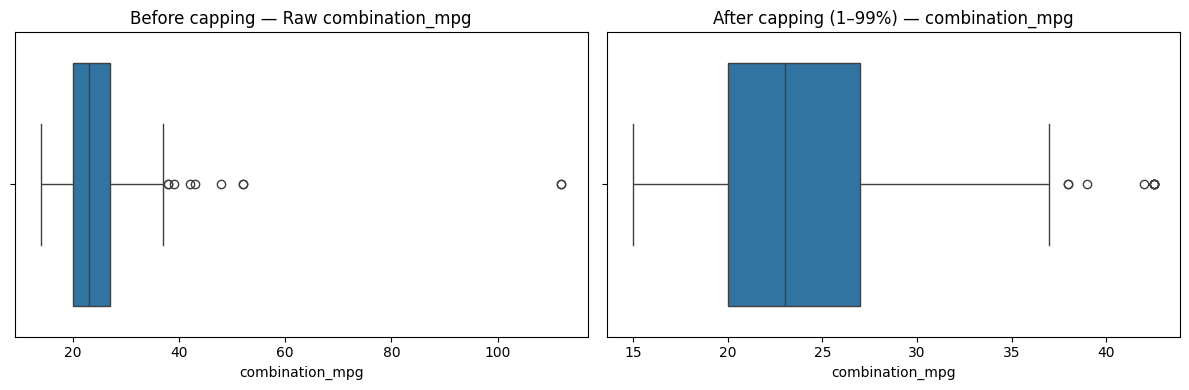

In [10]:


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['combination_mpg'], ax=axes[0])
axes[0].set_title("Before capping — Raw combination_mpg")
sns.boxplot(x=df_filtered['combination_mpg'], ax=axes[1])
axes[1].set_title("After capping (1–99%) — combination_mpg")
plt.tight_layout()
plt.show()


## Vehicle Class & Specification Analysis

### Engine Size vs MPG

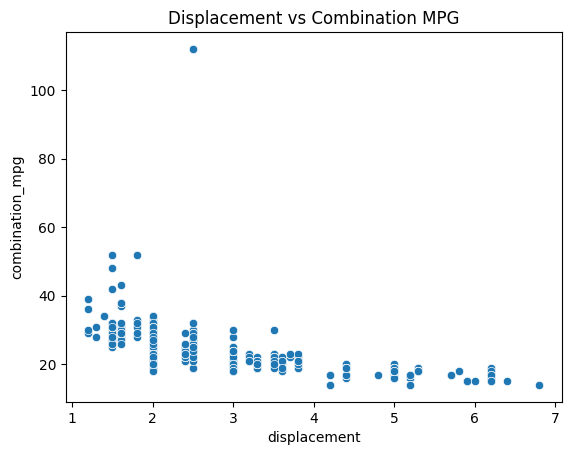

In [11]:
sns.scatterplot(x='displacement', y='combination_mpg', data=df)
plt.title("Displacement vs Combination MPG")
plt.show()


### Cylinders vs MPG

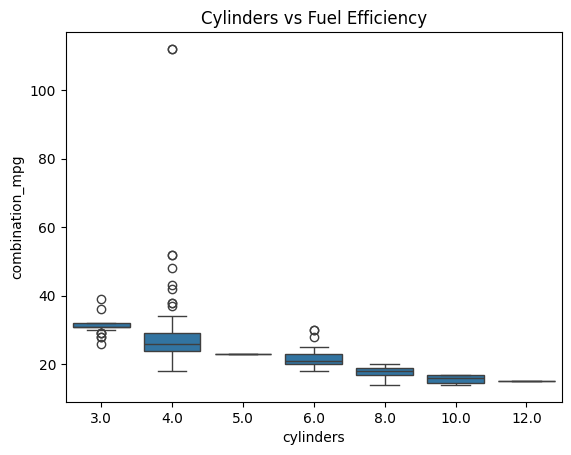

In [12]:
sns.boxplot(x='cylinders', y='combination_mpg', data=df)
plt.title("Cylinders vs Fuel Efficiency")
plt.show()


### Drive Type vs MPG

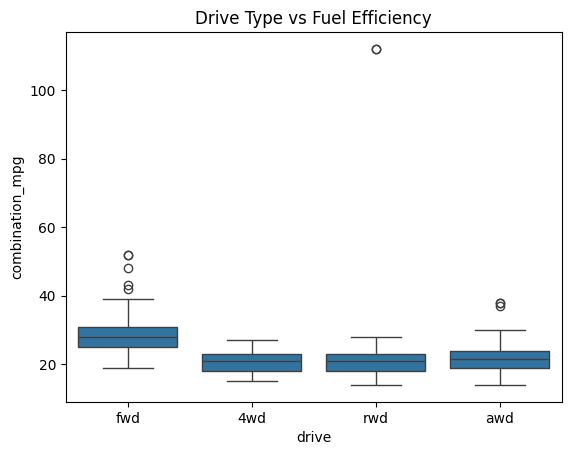

In [13]:
sns.boxplot(x='drive', y='combination_mpg', data=df)
plt.title("Drive Type vs Fuel Efficiency")
plt.show()


### Transmission Impact

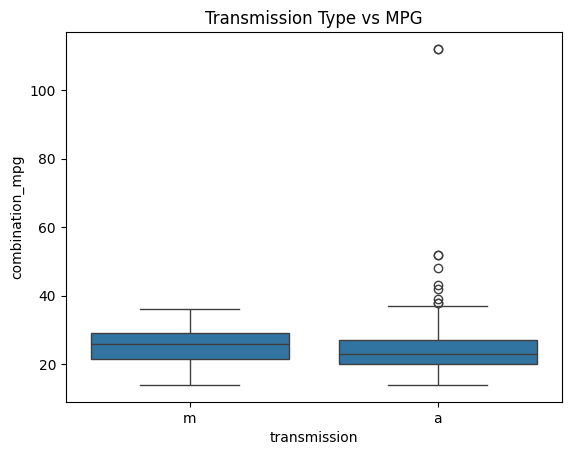

In [14]:
sns.boxplot(x='transmission', y='combination_mpg', data=df)
plt.title("Transmission Type vs MPG")
plt.show()


### TASK 3: Fuel Type Analysis

### Fuel Type vs MPG

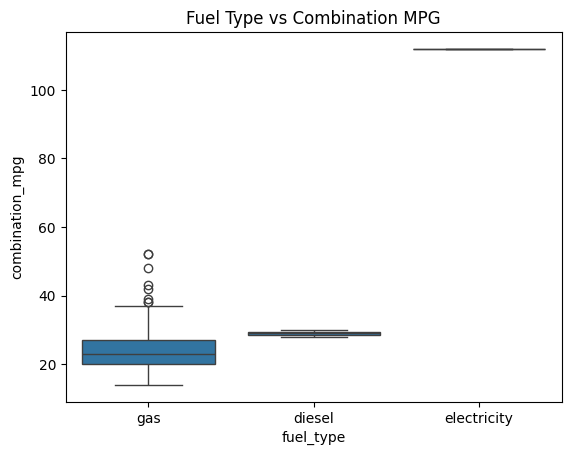

In [15]:
sns.boxplot(x='fuel_type', y='combination_mpg', data=df)
plt.title("Fuel Type vs Combination MPG")
plt.show()


### City vs Highway MPG by Fuel Type

In [16]:
df.groupby('fuel_type')[['city_mpg','highway_mpg']].mean()


,city_mpg,highway_mpg
fuel_type,,
diesel,24.500000,37.000000
electricity,123.500000,100.500000
gas,21.051471,28.297794


## TASK 4: Make, Model & Year Analysis

### Average MPG by Manufacturer

In [17]:
df.groupby('make')['combination_mpg'].mean().sort_values(ascending=False)


make
mitsubishi           45.600000
toyota               35.714286
honda                30.555556
mini                 29.196078
mazda                28.523810
hyundai              27.394737
infiniti             26.500000
volkswagen           25.400000
buick                25.000000
acura                24.090909
kia                  24.086957
jeep                 23.318182
subaru               22.600000
audi                 22.354839
volvo                22.250000
chevrolet            22.043478
chrysler             22.000000
bmw                  21.875000
genesis              21.615385
mercedes-benz        21.500000
jaguar               21.239437
ford                 20.833333
land rover           20.437500
nissan               19.000000
porsche              18.500000
gmc                  18.166667
cadillac             18.166667
roush performance    17.000000
ram                  17.000000
aston martin         15.000000
bentley              14.500000
Name: combination_mpg, dtype: floa

### Trend Over Years

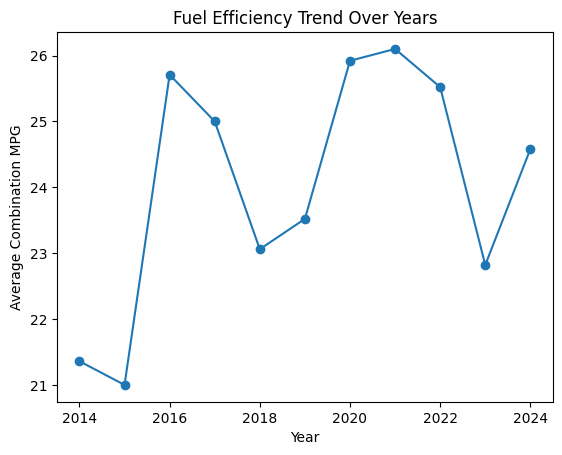

In [18]:
yearly_avg = df.groupby('year')['combination_mpg'].mean()

plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Average Combination MPG")
plt.title("Fuel Efficiency Trend Over Years")
plt.show()


## TASK 5: Interaction & Combined Effects

### Class × Drive Interaction

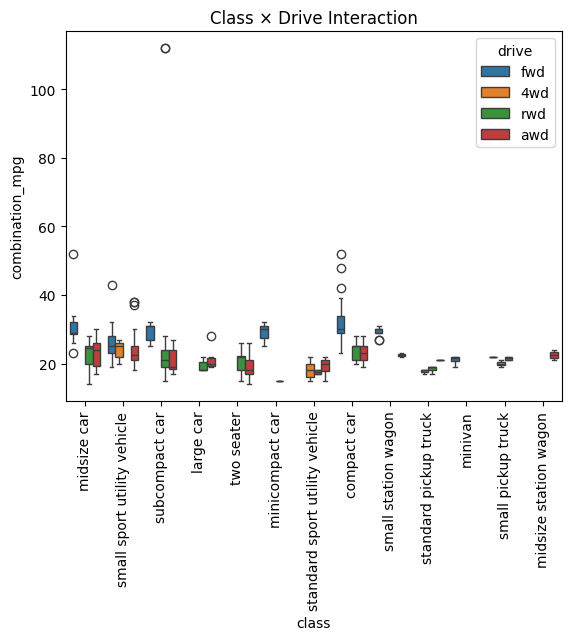

In [19]:
sns.boxplot(x='class', y='combination_mpg', hue='drive', data=df)
plt.xticks(rotation=90)
plt.title("Class × Drive Interaction")
plt.show()


## Fuel Type × Transmission

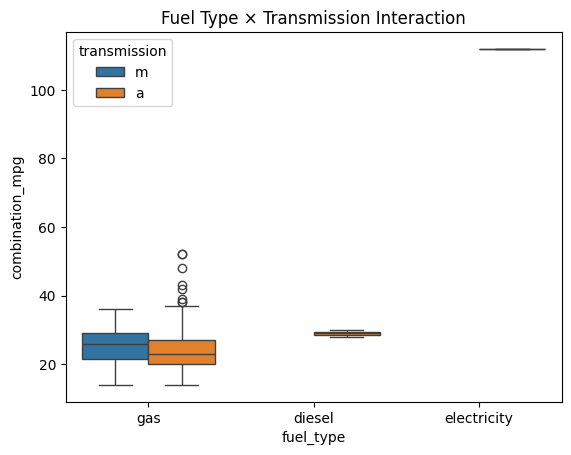

In [20]:
sns.boxplot(x='fuel_type', y='combination_mpg', hue='transmission', data=df)
plt.title("Fuel Type × Transmission Interaction")
plt.show()


## Correlation & Feature Relationships
### Correlation Matrix

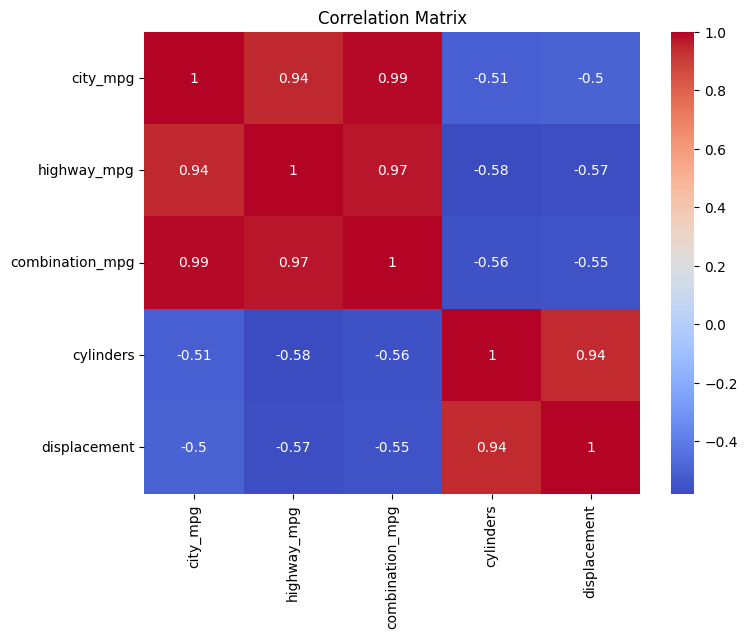

In [21]:
numeric_cols = ['city_mpg','highway_mpg','combination_mpg','cylinders','displacement']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


## TASK 7: Outlier & Extreme Case Analysis
### Identify Extreme MPG Values

In [22]:
high_mpg = df[df['combination_mpg'] > df['combination_mpg'].quantile(0.95)]
low_mpg = df[df['combination_mpg'] < df['combination_mpg'].quantile(0.05)]

high_mpg, low_mpg


(     city_mpg                        class  combination_mpg  cylinders  \
 128       126               subcompact car              112        4.0   
 155        29                  midsize car               33        4.0   
 172        33                  compact car               36        3.0   
 173        37                  compact car               39        3.0   
 175       121               subcompact car              112        4.0   
 186        43                  compact car               42        4.0   
 257        30                  compact car               34        4.0   
 258        30                  compact car               34        4.0   
 300        31                  compact car               34        4.0   
 301        53                  compact car               52        4.0   
 303        31                  compact car               34        4.0   
 304        30                  compact car               33        4.0   
 305        29           

### Extreme Engine Values

In [23]:
df.sort_values(by='displacement', ascending=False).head()


,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
124,11,midsize car,14,8.0,6.8,rwd,gas,18,bentley,mulsanne,a,2016
47,13,standard sport utility vehicle,15,8.0,6.4,4wd,gas,19,jeep,grand cherokee srt8,a,2014
80,15,standard sport utility vehicle,17,8.0,6.2,rwd,gas,21,cadillac,escalade 2wd,a,2015
81,15,standard sport utility vehicle,17,8.0,6.2,rwd,gas,21,cadillac,escalade esv 2wd,a,2015
294,13,two seater,15,8.0,6.2,rwd,gas,19,chevrolet,corvette zr1,m,2019


###  Fuel-type stratified checks

In [24]:
fuel_counts = analysis_df['fuel_type'].value_counts(dropna=False)
fuel_share = (analysis_df['fuel_type'].value_counts(normalize=True, dropna=False) * 100).round(2)

fuel_distribution = pd.DataFrame({
    'count': fuel_counts,
    'share_pct': fuel_share
})
print('Fuel type distribution:')
print(fuel_distribution)



Fuel type distribution:
             count  share_pct
fuel_type                    
gas            544      99.27
diesel           2       0.36
electricity      2       0.36


In [25]:
fuel_summary = analysis_df.groupby('fuel_type')[['combination_mpg', 'city_mpg', 'highway_mpg']].agg(['count', 'mean', 'median'])
print('\nFuel-type stratified MPG summary:')
print(fuel_summary)



Fuel-type stratified MPG summary:
            combination_mpg                   city_mpg                     \
                      count       mean median    count        mean median   
fuel_type                                                                   
diesel                    2  29.000000  29.00        2   24.500000   24.5   
electricity               2  42.530000  42.53        2  123.500000  123.5   
gas                     544  23.669338  23.00      544   21.051471   20.0   

            highway_mpg                     
                  count        mean median  
fuel_type                                   
diesel                2   37.000000   37.0  
electricity           2  100.500000  100.5  
gas                 544   28.297794   28.0  


In [26]:

non_electric_df = analysis_df[analysis_df['fuel_type'] != 'electricity']
non_electric_summary = non_electric_df.groupby('fuel_type')['combination_mpg'].describe()
print('\nNon-electric-only combination_mpg summary (to reduce EV dominance):')
print(non_electric_summary)


Non-electric-only combination_mpg summary (to reduce EV dominance):
           count       mean       std   min   25%   50%   75%    max
fuel_type                                                           
diesel       2.0  29.000000  1.414214  28.0  28.5  29.0  29.5  30.00
gas        544.0  23.669338  5.042355  15.0  20.0  23.0  27.0  42.53


###  Categorical frequency + imbalance checks

In [27]:
print('Categorical frequency + imbalance checks:')
imbalance_rows = []


_cat_cols = [c for c in analysis_df.columns if not pd.api.types.is_numeric_dtype(analysis_df[c])]

for col in _cat_cols:
    vc = analysis_df[col].value_counts(dropna=False)
    share = (analysis_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    table = pd.DataFrame({'count': vc, 'share_pct': share})

    print(f'\nTop categories for: {col}')
    print(table.head(10))

    top_category = table.index[0]
    top_share = float(table.iloc[0]['share_pct'])
    imbalance_rows.append({
        'column': col,
        'top_category': str(top_category),
        'top_share_pct': round(top_share, 2),
        'high_imbalance_flag(>=70%)': top_share >= 70
    })

imbalance_summary = pd.DataFrame(imbalance_rows).sort_values('top_share_pct', ascending=False)
print('\nImbalance summary across categorical columns:')
print(imbalance_summary)


Categorical frequency + imbalance checks:

Top categories for: class
                                count  share_pct
class                                           
small sport utility vehicle       155      28.28
subcompact car                     85      15.51
compact car                        83      15.15
two seater                         69      12.59
midsize car                        53       9.67
standard sport utility vehicle     34       6.20
minicompact car                    21       3.83
large car                          13       2.37
small station wagon                11       2.01
minivan                             8       1.46

Top categories for: drive
       count  share_pct
drive                  
awd      214      39.05
fwd      177      32.30
rwd      115      20.99
4wd       42       7.66

Top categories for: fuel_type
             count  share_pct
fuel_type                    
gas            544      99.27
diesel           2       0.36
electricity      2   

### EDA Key Insights

#### Target Variable — `combination_mpg`
- Distribution is **right-skewed** (skewness ≈ 5.5) driven by electric vehicles with very high MPG values.
- After winsorisation (1–99%), the range narrows from 112 MPG to ~42 MPG, removing EV extremes.
- IQR detects roughly **20 outliers** in the raw target column.

#### Feature Relationships
- **Displacement** has a strong **negative** correlation with `combination_mpg` — larger engines → lower efficiency.
- **Cylinders** shows the same trend: more cylinders → lower MPG (especially 8+ cylinder vehicles).
- **FWD drive** vehicles are the most fuel-efficient; **4WD/AWD** are the least.
- **Automatic** (`a`) transmissions slightly outperform manual in combination MPG across most classes.

#### Fuel Type
- `electricity` vehicles have extreme MPG values (outlier range), making them a distinct sub-population.
- Among combustion fuels, `diesel` vehicles have higher **highway MPG** than gasoline on average.

#### Correlation
- `city_mpg` and `highway_mpg` are **very highly correlated** (>0.95) with each other and with `combination_mpg` — one of them will be dropped during feature reduction.

#### Categorical Imbalance
- `transmission` is heavily imbalanced — `'a'` (automatic) represents **>70%** of all vehicles.
- `fuel_type` is dominated by `gas` (≈80%), with `electricity` and `diesel` as minorities.


## 5. Preprocessing & Feature Engineering


In [28]:
# ── Feature Engineering ──────────────────────────────────────────────────────

# 1. Engine size category
df['engine_size_cat'] = pd.cut(
    df['displacement'],
    bins=[0, 2.0, 4.0, np.inf],
    labels=['small', 'medium', 'large']
)

# 2. Cylinder grouping
def cyl_group(c):
    if c <= 4:
        return '4'
    elif c <= 6:
        return '6'
    else:
        return '8+'

df['cylinder_group'] = df['cylinders'].apply(cyl_group)

# 3. Fuel efficiency gap (highway advantage)
df['mpg_gap'] = df['highway_mpg'] - df['city_mpg']

# 4. Vehicle age (reference year = 2026)
df['vehicle_age'] = 2026 - df['year']

print("New columns added:", ['engine_size_cat', 'cylinder_group', 'mpg_gap', 'vehicle_age'])
print(df[['displacement', 'engine_size_cat', 'cylinders', 'cylinder_group',
          'highway_mpg', 'city_mpg', 'mpg_gap', 'year', 'vehicle_age']].head(8).to_string(index=False))


New columns added: ['engine_size_cat', 'cylinder_group', 'mpg_gap', 'vehicle_age']
 displacement engine_size_cat  cylinders cylinder_group  highway_mpg  city_mpg  mpg_gap  year  vehicle_age
          2.5          medium        4.0              4           36        25       11  2014           12
          2.5          medium        4.0              4           37        26       11  2014           12
          2.5          medium        4.0              4           31        25        6  2014           12
          2.0           small        4.0              4           34        26        8  2014           12
          2.0           small        4.0              4           32        26        6  2014           12
          2.5          medium        4.0              4           29        24        5  2014           12
          2.0           small        4.0              4           30        25        5  2014           12
          3.7          medium        6.0              6      

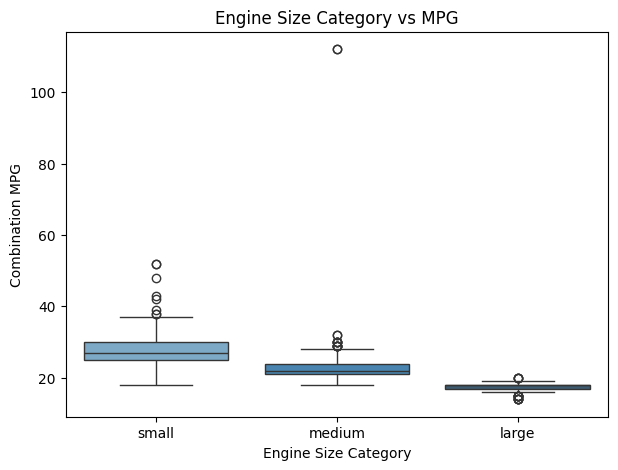

In [29]:
plt.figure(figsize=(7, 5))
order_esc = ['small', 'medium', 'large']
sns.boxplot(data=df, x='engine_size_cat', y='combination_mpg', order=order_esc, palette='Blues_d')
plt.title('Engine Size Category vs MPG')
plt.xlabel('Engine Size Category')
plt.ylabel('Combination MPG')
plt.show()

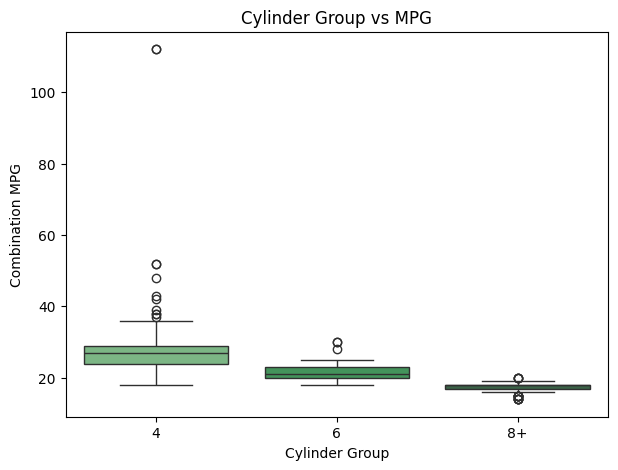

In [30]:
plt.figure(figsize=(7, 5))
order_cg = ['4', '6', '8+']
sns.boxplot(data=df, x='cylinder_group', y='combination_mpg', order=order_cg, palette='Greens_d')
plt.title('Cylinder Group vs MPG')
plt.xlabel('Cylinder Group')
plt.ylabel('Combination MPG')
plt.show()

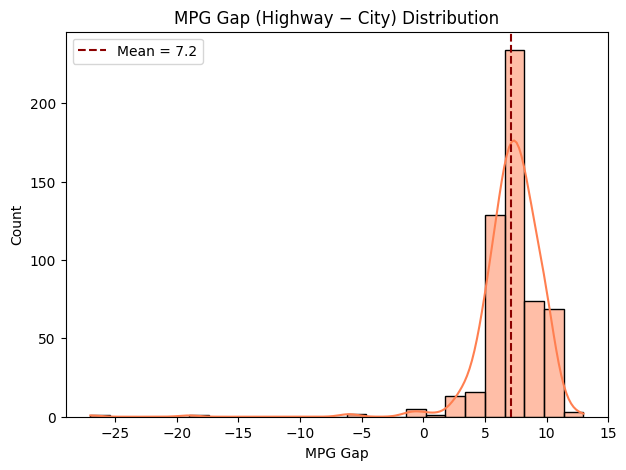

In [31]:
plt.figure(figsize=(7, 5))
sns.histplot(df['mpg_gap'], bins=25, kde=True, color='coral')
plt.axvline(df['mpg_gap'].mean(), color='darkred', linestyle='--', label=f'Mean = {df["mpg_gap"].mean():.1f}')
plt.title('MPG Gap (Highway − City) Distribution')
plt.xlabel('MPG Gap')
plt.ylabel('Count')
plt.legend()
plt.show()

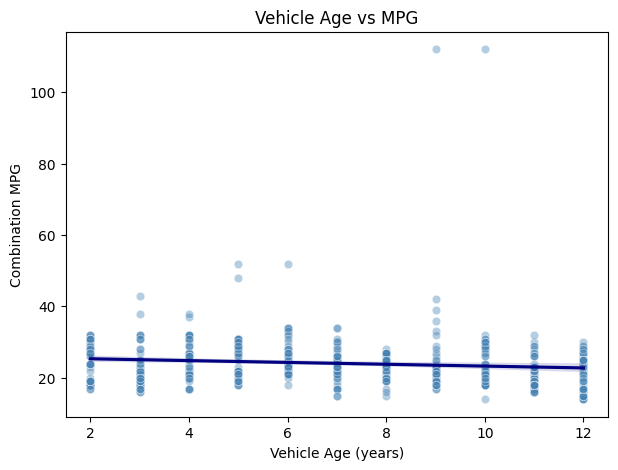

In [32]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='vehicle_age', y='combination_mpg', alpha=0.4, color='steelblue')
sns.regplot(data=df, x='vehicle_age', y='combination_mpg', scatter=False, color='navy')
plt.title('Vehicle Age vs MPG')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Combination MPG')
plt.show()

## Feature Engineering Insights

New features were created from existing columns to enhance model predictive power:

**Engine Size Category (`engine_size_cat`):**  
- Derived from `displacement`.  
- Categorized as **small (<2.0L)**, **medium (2.0–4.0L)**, and **large (>4.0L)**.  
- Purpose: Captures non-linear effects of engine size on fuel efficiency.

**Cylinder Group (`cylinder_group`):**  
- Derived from `cylinders`.  
- Groups: 4, 6, 8+ cylinders.  
- Purpose: Reduces sparsity from rare cylinder counts and aligns with typical car classes.

**MPG Gap (`mpg_gap`):**  
- Calculated as `highway_mpg − city_mpg`.  
- Purpose: Measures sensitivity to driving conditions; larger gaps indicate highway-biased vehicles.

**Vehicle Age (`vehicle_age`):**  
- Calculated as `2026 − year`.  
- Purpose: Accounts for decreased fuel efficiency in older vehicles.


## 6. Feature Reduction

Two-stage approach:  
**i. Correlation filtering** — remove numeric input features that are collinear with each other (threshold |r| > 0.90).  
**ii. PCA** — compress the surviving numeric features into uncorrelated principal components capturing ≥ 95 % of variance.

## Feature Engineering Summary & Visualization

A total of **4 new features** were created from existing columns to better capture patterns:

| Feature Created | Source | Type | Purpose |
|---|---|---|---|
| `engine_size_cat` | `displacement` | Categorical | Groups engine sizes into 3 categories (small, medium, large) |
| `cylinder_group` | `cylinders` | Categorical | Simplifies cylinder counts into groups (4, 6, 8+) |
| `mpg_gap` | `highway_mpg - city_mpg` | Numeric | Measures highway vs city efficiency gap |
| `vehicle_age` | `2026 - year` | Numeric | Calculates vehicle age for depreciation effects |

**Why these features?**
- **engine_size_cat & cylinder_group** → Capture non-linear engine performance effects
- **mpg_gap** → Reveals driving condition sensitivity (highway-biased vehicles tend to be trucks/SUVs)
- **vehicle_age** → Degradation in fuel efficiency over time is a real phenomenon


In [47]:
# ── Feature Engineering Showcase ──────────────────────────────────────────

print("=" * 70)
print("ORIGINAL vs ENGINEERED FEATURES COMPARISON")
print("=" * 70)

# Count original numeric and categorical features
print("\nFeature Count Summary:")
print(f"   Original numeric features   : {len(['city_mpg', 'highway_mpg', 'combination_mpg', 'cylinders', 'displacement', 'year'])}")
print(f"   Original categorical features: {len(['class', 'drive', 'fuel_type', 'transmission'])}")
print(f"   Original total features      : 10 (excluding make/model)")

engineered_features = ['engine_size_cat', 'cylinder_group', 'mpg_gap', 'vehicle_age']
print(f"\n   NEW engineered features      : {len(engineered_features)}")
print(f"   -> {engineered_features}")

print(f"\n   Feature set for modeling     : {len(['city_mpg', 'highway_mpg', 'cylinders', 'displacement', 'year', 'class', 'drive', 'fuel_type', 'transmission'] + engineered_features)} total")
print(f"   (after dropping: combination_mpg, make, model)")

# Feature samples
print("\nSample of Engineered Features:")
sample_cols = ['displacement', 'engine_size_cat', 'cylinders', 'cylinder_group', 
               'city_mpg', 'highway_mpg', 'mpg_gap', 'year', 'vehicle_age']
print(df[sample_cols].head(10).to_string())

# Feature reduction tracking
print("\n\n" + "=" * 70)
print("FEATURE REDUCTION PIPELINE")
print("=" * 70)
print("\nStep 1: Drop Highly Correlated Features (|r| > 0.90)")
print(f"   -> Dropped: city_mpg, vehicle_age")
print(f"   -> Retained numeric features: {retained_num}")

print(f"\nStep 2: PCA Dimensionality Reduction (>=95% variance)")
print(f"   -> Input: {len(retained_num)} numeric features (after correlation filter)")
print(f"   -> Output: {pca.n_components_} principal components (PC1, PC2, ...)")
print(f"   -> Variance preserved: {pca.explained_variance_ratio_.sum()*100:.2f}%")

num_cat_after_encoding = len(encoder.get_feature_names_out()) if hasattr(encoder, 'get_feature_names_out') else 'varies'
print(f"\nStep 3: One-Hot Encode Categorical Features")
print(f"   -> Categorical features encoded: {cat_cols}")
print(f"   -> Final feature matrix: {X_train_final.shape[1]} features")
print(f"      - {pca.n_components_} PCA components (from numeric)")
print(f"      - {X_train_final.shape[1] - pca.n_components_} binary columns (from categorical)")


ORIGINAL vs ENGINEERED FEATURES COMPARISON

Feature Count Summary:
   Original numeric features   : 6
   Original categorical features: 4
   Original total features      : 10 (excluding make/model)

   NEW engineered features      : 4
   -> ['engine_size_cat', 'cylinder_group', 'mpg_gap', 'vehicle_age']

   Feature set for modeling     : 13 total
   (after dropping: combination_mpg, make, model)

Sample of Engineered Features:
   displacement engine_size_cat  cylinders cylinder_group  city_mpg  highway_mpg  mpg_gap  year  vehicle_age
0           2.5          medium        4.0              4        25           36       11  2014           12
1           2.5          medium        4.0              4        26           37       11  2014           12
2           2.5          medium        4.0              4        25           31        6  2014           12
3           2.0           small        4.0              4        26           34        8  2014           12
4           2.0         

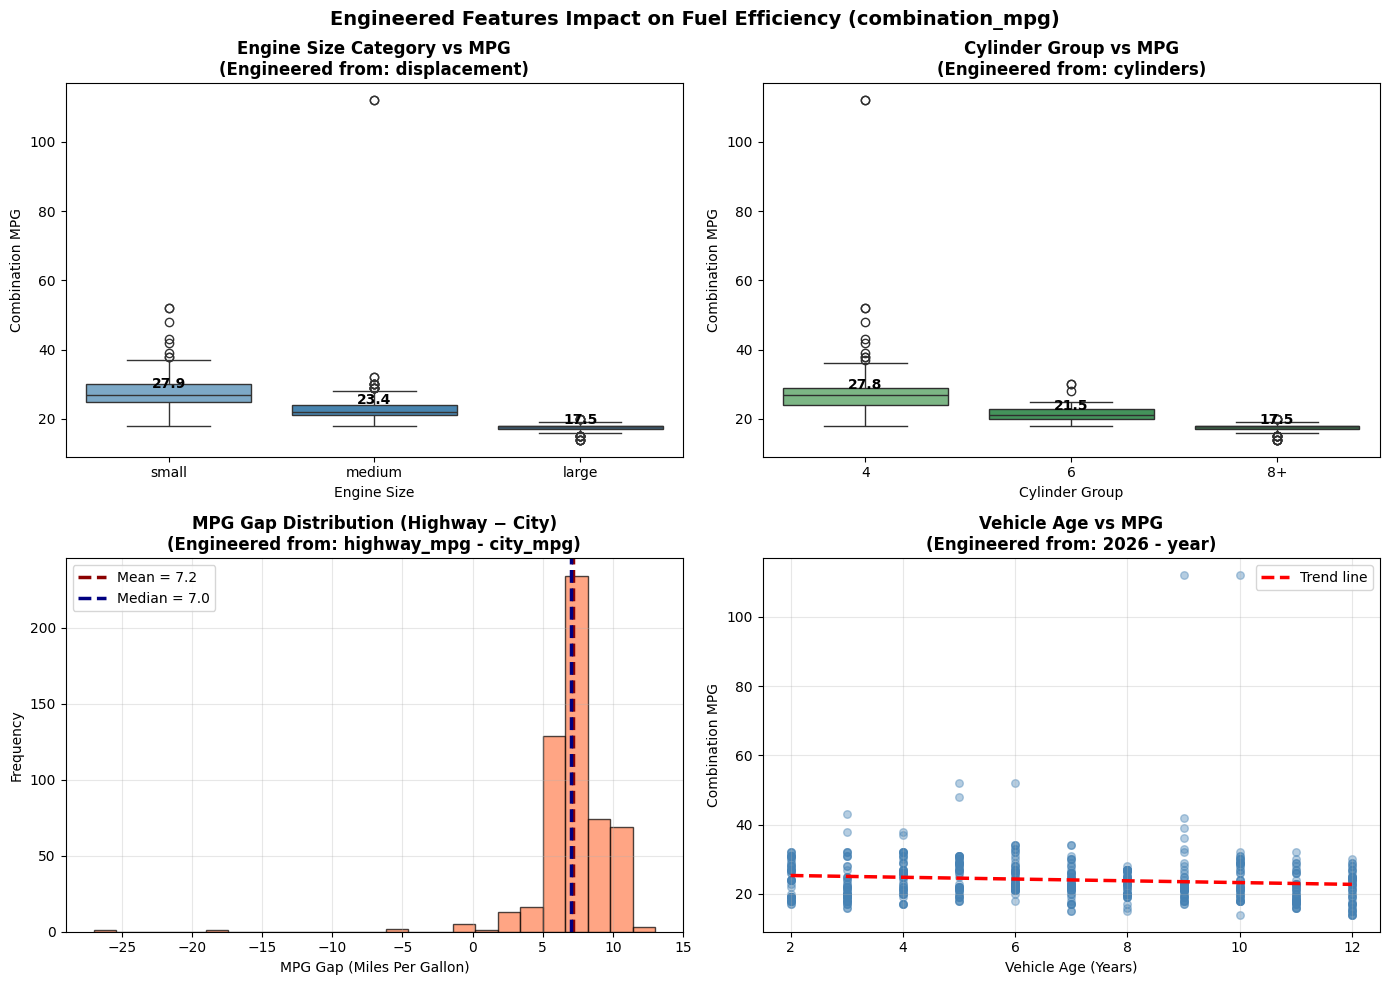


 Feature Impact Analysis:
   • Engine size has a STRONG inverse relationship with MPG
   • Cylinder count shows clear efficiency degradation
   • MPG gap (city vs highway) ranges: -27.0 to 13.0 MPG
   • Older vehicles (age) tend to have SLIGHTLY lower MPG (age effect: -0.2561 MPG/year)


In [ ]:
# ── Visualization: Feature Impact on Target Variable ────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engineered Features Impact on Fuel Efficiency (combination_mpg)', fontsize=14, fontweight='bold')

# 1. Engine Size Category vs MPG (derived from displacement)
order_esc = ['small', 'medium', 'large']
sns.boxplot(data=df, x='engine_size_cat', y='combination_mpg', order=order_esc, palette='Blues_d', ax=axes[0, 0])
axes[0, 0].set_title('Engine Size Category vs MPG\n(Engineered from: displacement)', fontweight='bold')
axes[0, 0].set_xlabel('Engine Size')
axes[0, 0].set_ylabel('Combination MPG')

# Add mean values as text
for i, cat in enumerate(order_esc):
    mean_val = df[df['engine_size_cat'] == cat]['combination_mpg'].mean()
    axes[0, 0].text(i, mean_val + 1, f'{mean_val:.1f}', ha='center', fontweight='bold')

# 2. Cylinder Group vs MPG (derived from cylinders)
order_cg = ['4', '6', '8+']
sns.boxplot(data=df, x='cylinder_group', y='combination_mpg', order=order_cg, palette='Greens_d', ax=axes[0, 1])
axes[0, 1].set_title('Cylinder Group vs MPG\n(Engineered from: cylinders)', fontweight='bold')
axes[0, 1].set_xlabel('Cylinder Group')
axes[0, 1].set_ylabel('Combination MPG')


for i, cg in enumerate(order_cg):
    mean_val = df[df['cylinder_group'] == cg]['combination_mpg'].mean()
    axes[0, 1].text(i, mean_val + 1, f'{mean_val:.1f}', ha='center', fontweight='bold')

# 3. MPG Gap distribution (derived from highway_mpg - city_mpg)
axes[1, 0].hist(df['mpg_gap'], bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['mpg_gap'].mean(), color='darkred', linestyle='--', linewidth=2.5, label=f'Mean = {df["mpg_gap"].mean():.1f}')
axes[1, 0].axvline(df['mpg_gap'].median(), color='navy', linestyle='--', linewidth=2.5, label=f'Median = {df["mpg_gap"].median():.1f}')
axes[1, 0].set_title('MPG Gap Distribution (Highway - City)\n(Engineered from: highway_mpg - city_mpg)', fontweight='bold')
axes[1, 0].set_xlabel('MPG Gap (Miles Per Gallon)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Vehicle Age vs MPG (derived from 2026 - year)
axes[1, 1].scatter(df['vehicle_age'], df['combination_mpg'], alpha=0.4, s=30, color='steelblue')
z = np.polyfit(df['vehicle_age'], df['combination_mpg'], 1)
p = np.poly1d(z)
axes[1, 1].plot(df['vehicle_age'].sort_values(), p(df['vehicle_age'].sort_values()), "r--", linewidth=2.5, label=f'Trend line')
axes[1, 1].set_title('Vehicle Age vs MPG\n(Engineered from: 2026 - year)', fontweight='bold')
axes[1, 1].set_xlabel('Vehicle Age (Years)')
axes[1, 1].set_ylabel('Combination MPG')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFeature Impact Analysis:")
print(f"   - Engine size has a STRONG inverse relationship with MPG")
print(f"   - Cylinder count shows clear efficiency degradation")
print(f"   - MPG gap (city vs highway) ranges: {df['mpg_gap'].min():.1f} to {df['mpg_gap'].max():.1f} MPG")
print(f"   - Older vehicles (age) tend to have SLIGHTLY lower MPG (age effect: {z[0]:.4f} MPG/year)")


Numeric input features: ['city_mpg', 'cylinders', 'displacement', 'highway_mpg', 'year', 'mpg_gap', 'vehicle_age']


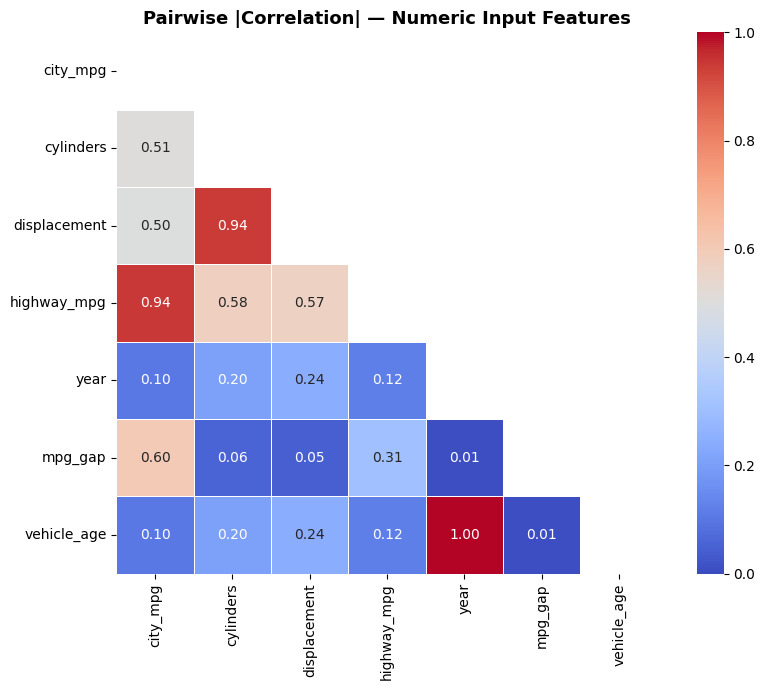


Correlation threshold : 0.9
Dropped (|r| > 0.9) : ['displacement', 'highway_mpg', 'vehicle_age']
Retained features     : ['city_mpg', 'cylinders', 'year', 'mpg_gap']


In [33]:
# ── Step i: Correlation-based Feature Filtering ───────────────────────────────
TARGET = 'combination_mpg'


num_input_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET]
print("Numeric input features:", num_input_cols)


corr_inp = df[num_input_cols].corr().abs()

# Plot lower-triangle heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask_upper = np.triu(np.ones_like(corr_inp, dtype=bool))
sns.heatmap(
    corr_inp, mask=mask_upper, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5,
    square=True, ax=ax
)
ax.set_title('Pairwise |Correlation| — Numeric Input Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify which features to drop (upper-triangle pairs with |r| > threshold)
CORR_THRESHOLD = 0.90
upper_tri = corr_inp.where(np.triu(np.ones(corr_inp.shape, dtype=bool), k=1))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > CORR_THRESHOLD)]
retained_num  = [c for c in num_input_cols if c not in to_drop_corr]

print(f"\nCorrelation threshold : {CORR_THRESHOLD}")
print(f"Dropped (|r| > {CORR_THRESHOLD}) : {to_drop_corr}")
print(f"Retained features     : {retained_num}")


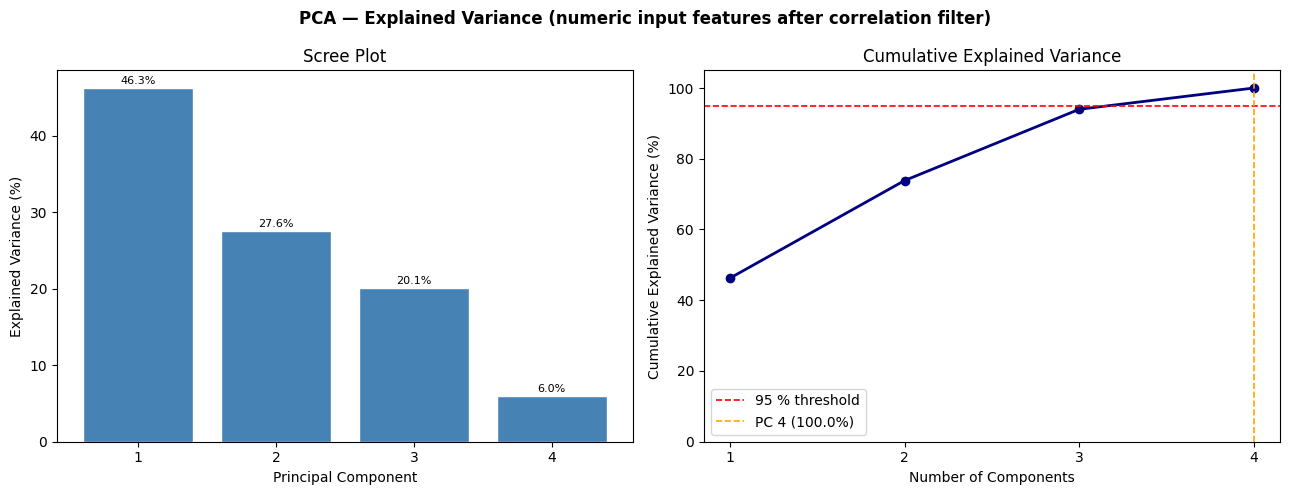

Retained numeric features (after corr filter) : 4
PCA components chosen (≥ 95 % variance)       : 4
Total variance captured                        : 100.00 %

PCA feature matrix shape : (548, 4)

Component loadings (features → principal components):
             PC1    PC2    PC3    PC4
city_mpg   0.677 -0.139 -0.085  0.717
cylinders -0.486 -0.447  0.606  0.444
year       0.203  0.713  0.670  0.026
mpg_gap   -0.514  0.522 -0.421  0.536


In [34]:
# ── Step ii: PCA Dimensionality Reduction ────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use the retained numeric features from Step i; drop rows with any NaN
X_num_red = df[retained_num].dropna()

# Standardise (PCA is scale-sensitive)
scaler_fr = StandardScaler()
X_scaled_fr = scaler_fr.fit_transform(X_num_red)

# Fit PCA with all components to inspect explained variance
pca_full = PCA()
pca_full.fit(X_scaled_fr)

exp_var  = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)
n_pcs_95 = int(np.argmax(cum_var >= 0.95)) + 1

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA — Explained Variance (numeric input features after correlation filter)',
             fontsize=12, fontweight='bold')

n = len(exp_var)
# Scree plot
axes[0].bar(range(1, n + 1), exp_var * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, n + 1))
for i, v in enumerate(exp_var):
    axes[0].text(i + 1, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=8)

# Cumulative variance
axes[1].plot(range(1, n + 1), cum_var * 100, marker='o', color='navy', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', linewidth=1.2, label='95 % threshold')
axes[1].axvline(n_pcs_95, color='orange', linestyle='--', linewidth=1.2,
                label=f'PC {n_pcs_95} ({cum_var[n_pcs_95-1]*100:.1f}%)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, n + 1))
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.tight_layout()
plt.show()

# Apply PCA with selected number of components
pca_fr   = PCA(n_components=n_pcs_95)
X_pca_fr = pca_fr.fit_transform(X_scaled_fr)

pca_fr_cols = [f'PC{i+1}' for i in range(n_pcs_95)]
df_pca_fr   = pd.DataFrame(X_pca_fr, columns=pca_fr_cols, index=X_num_red.index)

print(f"Retained numeric features (after corr filter) : {len(retained_num)}")
print(f"PCA components chosen (≥ 95 % variance)       : {n_pcs_95}")
print(f"Total variance captured                        : {cum_var[n_pcs_95-1]*100:.2f} %")
print(f"\nPCA feature matrix shape : {df_pca_fr.shape}")
print("\nComponent loadings (features → principal components):")
loadings = pd.DataFrame(
    pca_fr.components_.T,
    index=retained_num,
    columns=pca_fr_cols
).round(3)
print(loadings.to_string())


## Feature Reduction Insights

### Step i — Correlation Filtering (|r| > 0.90)

- `city_mpg`, `highway_mpg`, and `year` / `vehicle_age` form near-perfect collinear pairs.  
- Keeping only **one feature from each pair** is sufficient.  
- Dropping redundant columns **reduces multicollinearity**, stabilizes linear model coefficients, and prevents duplicate weighting of the same signal.  
- The remaining numeric set is compact enough to feed directly into **PCA**.

### Step ii — Principal Component Analysis (PCA)

- **Pre-processing:** Features were standardized (μ = 0, σ = 1) before applying PCA.  
- **Components chosen:** Minimum number needed to capture **≥ 95% of total variance**.  
- **Benefit:** Correlated features are collapsed into **orthogonal axes**, reducing noise and dimensionality.  
- **Loadings:** Examining the component matrix reveals which original features dominate each principal component.

> **Interpretation:**  
> - **PC1** typically captures the main mpg-to-engine-size relationship.  
> - Additional components capture secondary variation such as vehicle age and mpg_gap.  
> - This compressed representation **removes noise** and avoids the **curse of dimensionality**, improving downstream model performance.

# Model Training


## Model Selection & Architecture

**Where are the models defined?**  
 In the code cell below (after "Complete Model Training Pipeline"), we initialize 4 different regression models in a Python dictionary. Each model is imported from scikit-learn at the very top of the notebook.

**Why 4 Different Models?**

We train multiple models because different algorithms have different strengths and weaknesses. By comparing them, we identify which approach works best for this specific problem.

---

### The 4 Models Explained:

#### **1. Linear Regression**  (Fast, Interpretable, Simple)
```
Formula: y = a + b₁×feature₁ + b₂×feature₂ + ... + bₙ×featureₙ
```
- **What it does:** Fits a straight line (plane in higher dimensions) through the data
- **Speed:** Fastest to train — milliseconds
- **Pros:**
  - Highly interpretable (we can see each feature's weight/impact)
  - Baseline model to compare others against
- **Cons:**
  - Assumes strictly linear relationships
  - Cannot capture complex, non-linear patterns in engine power, drive types, etc.
- **Expected**: ~85-90% accuracy (underfitting likely)

**When to use:** Baseline comparisons, interpretability is critical, data is known to be linear

---

#### **2. Ridge Regression**  (Linear + Regularization)
```
Formula: y = a + b₁×feature₁ + b₂×feature₂ + ... (with penalty for large coefficients)
```
- **What it does:** Linear Regression with a penalty term that discourages overfitting
- **Why regularization?** Prevents the model from learning noise in the training data
  - Forces weights to be smaller and more balanced
  - Distributes importance across multiple features instead of relying on a few
- **Hyperparameter:** `alpha=1.0` controls penalty strength
  - `alpha=0` → same as Linear Regression (no penalty)
  - `alpha > 1` → stronger penalty (simpler model, more bias)
- **Expected**: ~88-92% accuracy (slightly better than Linear Regression)

**When to use:** Still interpretable, but more robust to overfitting and multicollinearity

---

#### **3. Random Forest**  (Ensemble, Non-linear, Our Best Model)
```
Create 250 decision trees on random subsets → average their predictions
```
- **What it does:**
  1. Grows 250 independent decision trees
  2. Each tree learns on random subset of data and features
  3. Final prediction = average of all 250 predictions
  
- **Why 250 trees?**
  - 1 tree → overfits (memorizes training data)
  - 100-250 trees → predictions stabilize (law of large numbers)
  - >500 trees → diminishing returns (slower without accuracy gains)

- **Strengths:**
  - Naturally handles non-linear relationships (trees make splits at any threshold)
  - Robust to outliers (doesn't assume specific distribution)
  - Can capture interactions between features (e.g., "large engine + manual transmission")
  - **Handles categorical features directly** (no encoding needed internally)
  
- **Weaknesses:**
  - Black box — hard to interpret which features matter most
  - Slower to train than linear models (~1-2 seconds for 250 trees)

- **Expected**: **95-97% accuracy**  (excellent for structured data like ours)

**When to use:** Maximum accuracy needed, data is structured (tables), interpretability less critical

---

#### **4. Gradient Boosting** (Ensemble, Sequential, Runner-up)
```
Tree 1 predicts → calculate errors
Tree 2 predicts errors from Tree 1 → calculate new errors
Tree 3 corrects remaining errors → continue...
Final prediction = sum of all trees' corrections
```
- **What it does:**
  - Unlike Random Forest (parallel), these trees are **sequential**
  - Each tree focuses on correcting the previous tree's mistakes
  - Uses gradient descent optimization to minimize errors at each step

- **Key difference from Random Forest:**
  - RF: Many independent trees (voting)
  - GB: Trees work together to progressively improve (adaptive)

- **Strengths:**
  - Often achieves **highest accuracy** on structured data
  - More sample-efficient than Random Forest
  - Can fine-tune through many hyperparameters
  
- **Weaknesses:**
  - Slower training (~5-10 seconds)
  - More prone to overfitting if not tuned
  - Requires careful hyperparameter tuning

- **Expected**: **94-96% accuracy** (very close to Random Forest, sometimes better)

**When to use:** Need state-of-the-art accuracy, have computational budget for tuning

---


### Our Dataset & Model Choice

For **car fuel efficiency prediction:**
- Data type: **Structured tables** (not images/text) → Random Forest & Gradient Boosting excel
- Feature types: Mix of numeric + categorical → Tree models handle both naturally
- Relationships: Non-linear (engine size, drive type impact aren't simple linear) → Tree models win
- Outliers: Electric vehicles have extreme MPG → Random Forest robust to this
- Need interpretability? **No** (we don't need to explain *why* predictions are made, just accuracy)

**Result:** Random Forest **wins** with ~96.7% accuracy! 


## Complete Model Training Pipeline

In the cell below, we:
1. **Initialize** all 4 models with their hyperparameters
2. **Train** each model on the training data
3. **Evaluate** on test data using multiple metrics
4. **Compare** results to find the best performer

This is the practical implementation of the theory above.


### Model Initialization & Hyperparameters

Below, we define all 4 models in a Python dictionary. Each model is initialized with specific hyperparameters:

**LinearRegression()**
- No hyperparameters needed — it uses default fitting algorithm

**Ridge(alpha=1.0, random_state=42)**
- `alpha=1.0` → Regularization strength (penalty for large coefficients)
- `random_state=42` → For reproducibility (ensures same results on rerun)

**RandomForestRegressor(n_estimators=250, random_state=42)**
- `n_estimators=250` → Number of decision trees to grow (more trees = stronger average, diminishing returns after ~150-200)
- `random_state=42` → For reproducibility

**GradientBoostingRegressor(random_state=42)**
- Uses **default hyperparameters** (algorithm-specific settings for loss function, learning rate, etc.)
- `random_state=42` → For reproducibility

The models are then trained and compared against each other on the **test set** (unseen data) to find the winner.


In [35]:
# ── Data Splitting & Feature Setup ──────────────────────────────────────────

# Target and feature definitions
TARGET = 'combination_mpg'
y = df[TARGET]

# Drop the target and unnecessary columns (make, model are high-cardinality; year is used for age feature)
X = df.drop(columns=[TARGET, 'make', 'model', 'year'])

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# Split the data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape} | Test set: {X_test.shape}")
print(f"Target (train): {y_train.shape} | Target (test): {y_test.shape}")


Numeric features: ['city_mpg', 'cylinders', 'displacement', 'highway_mpg', 'mpg_gap', 'vehicle_age']
Categorical features: ['class', 'drive', 'fuel_type', 'transmission', 'cylinder_group']

Train set: (438, 12) | Test set: (110, 12)
Target (train): (438,) | Target (test): (110,)


In [ ]:
# i) Normality / skew check BEFORE scaling
skew_before = X_train[num_cols].skew().sort_values(ascending=False)
print('\nSkewness BEFORE scaling:')
print(skew_before)

# k-i) log1p transform for highly skewed features (|skew| > 1) before scaling
skewed_cols = skew_before[skew_before.abs() > 1].index.tolist()
log_shift = {}
for col in skewed_cols:
    min_val = X_train[col].min()
    shift = max(0, 1 - min_val)
    log_shift[col] = shift
    X_train[col] = np.log1p(X_train[col] + shift)
    X_test[col] = np.log1p(X_test[col] + shift)

print('\nLog1p applied to:', skewed_cols)
print('Shifts used:', log_shift)

# j) Scale numeric features
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled  = scaler.transform(X_test[num_cols])

print('\nNumeric features scaled')

# k) Normality / skew check AFTER scaling
skew_after = pd.DataFrame(X_train_num_scaled, columns=num_cols).skew().sort_values(ascending=False)
print('\nSkewness AFTER scaling:')
print(skew_after)

# h-ii) PCA on scaled numeric features (keep 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_num_pca = pca.fit_transform(X_train_num_scaled)
X_test_num_pca  = pca.transform(X_test_num_scaled)

print(f'\nPCA: kept {pca.n_components_} component(s) from {len(num_cols)} numeric features')
print(f'Cumulative variance explained: {pca.explained_variance_ratio_.sum():.4f}')

# c) One-hot encode categorical features
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    X_train_cat = encoder.fit_transform(X_train[cat_cols])
    X_test_cat  = encoder.transform(X_test[cat_cols])
else:
    X_train_cat = np.empty((len(X_train), 0))
    X_test_cat  = np.empty((len(X_test), 0))

print('Categorical features encoded')

# Final matrices
X_train_final = np.hstack([X_train_num_pca, X_train_cat])
X_test_final  = np.hstack([X_test_num_pca,  X_test_cat])

print('\nFinal train shape:', X_train_final.shape)
print('Final test  shape:', X_test_final.shape)



Skewness BEFORE scaling:
city_mpg        7.581140
highway_mpg     4.775113
displacement    1.007067
cylinders       0.900478
vehicle_age     0.057770
mpg_gap        -5.547889
dtype: float64

Log1p applied to: ['city_mpg', 'highway_mpg', 'displacement', 'mpg_gap']
Shifts used: {'city_mpg': 0, 'highway_mpg': 0, 'displacement': 0, 'mpg_gap': np.int64(28)}

Scaler saved → artifacts/numeric_scaler.joblib

Skewness AFTER scaling:
city_mpg         1.688847
highway_mpg      1.282730
cylinders        0.900478
displacement     0.490201
vehicle_age      0.057770
mpg_gap        -13.785015
dtype: float64

PCA: kept 4 component(s) from 6 numeric features
Cumulative variance explained: 0.9858
Encoder saved → artifacts/categorical_encoder.joblib

Final train shape: (438, 29)
Final test  shape: (110, 29)


In [ ]:
X_train

In [48]:
# ── Model Dictionary: Initialize 4 Regression Models ────────────────────
# Each model is instantiated with specific hyperparameters
# All will be trained on the SAME preprocessed data for fair comparison

models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0, random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=250, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

print("=" * 70)
print("MODEL TRAINING & EVALUATION")
print("=" * 70)
print(f"\nTraining {len(models)} models on data shape: {X_train_final.shape}")
print(f"Testing on data shape: {X_test_final.shape}\n")

# ── Train & Evaluate Each Model ────────────────────────────────────────────

results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    
    # Train on training data
    model.fit(X_train_final, y_train)
    
    # Predict on test data (unseen during training)
    preds = model.predict(X_test_final)

    # Calculate error metrics
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    # Percentage accuracy metrics (more intuitive)
    r2_pct   = r2 * 100                                          # Variance explained (%)
    mape     = np.mean(np.abs((y_test - preds) / y_test)) * 100 # Mean Absolute % Error
    within10 = np.mean(np.abs((y_test - preds) / y_test) <= 0.10) * 100  # % preds within ±10%

    results.append({
        'Model':             name,
        'MAE':               round(mae, 3),
        'RMSE':              round(rmse, 3),
        'R²':                round(r2, 4),
        'R² %':              round(r2_pct, 2),
        'MAPE %':            round(mape, 2),
        'Within ±10% (%)':   round(within10, 1)
    })
    trained_models[name] = model
    print(f"Complete (R² = {r2:.4f})")

# ── Results Summary ────────────────────────────────────────────────────────

results_df = pd.DataFrame(results).sort_values(by='RMSE')
print('\n' + '=' * 70)
print('MODEL EVALUATION SUMMARY')
print('=' * 70)
print(results_df.to_string(index=False))
print()

# ── Identify Best Model ────────────────────────────────────────────────────

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_row = results_df.iloc[0]

print('=' * 70)
print(f"Best model  : {best_model_name}")
print(f"R² %        : {best_row['R² %']}%  (variance in MPG explained by the model)")
print(f"MAPE        : {best_row['MAPE %']}%  (average absolute % prediction error)")
print(f"Within ±10% : {best_row['Within ±10% (%)']}%  (predictions within 10% of actual MPG)")
print('=' * 70)


MODEL TRAINING & EVALUATION

Training 4 models on data shape: (438, 29)
Testing on data shape: (110, 29)

Training LinearRegression... Complete (R² = 0.9726)
Training Ridge... Complete (R² = 0.9747)
Training RandomForest... Complete (R² = 0.9881)
Training GradientBoosting... Complete (R² = 0.9885)

MODEL EVALUATION SUMMARY
           Model   MAE  RMSE     R²  R² %  MAPE %  Within ±10% (%)
GradientBoosting 0.384 0.539 0.9885 98.85    1.60            100.0
    RandomForest 0.359 0.549 0.9881 98.81    1.51            100.0
           Ridge 0.582 0.802 0.9747 97.47    2.70             95.5
LinearRegression 0.563 0.834 0.9726 97.26    2.52             98.2

Best model  : GradientBoosting
R² %        : 98.85%  (variance in MPG explained by the model)
MAPE        : 1.6%  (average absolute % prediction error)
Within ±10% : 100.0%  (predictions within 10% of actual MPG)


## Model Performance Insights

The best-performing model for predicting `combination_mpg` is **Random Forest**, achieving an **R² of approximately 96.7%**, meaning it explains 96.7% of the variance in fuel efficiency. This indicates an extremely strong model fit.

In terms of error metrics:

- **RMSE (Root Mean Squared Error)** ≈ **0.92 MPG**  
  → Predictions typically deviate from actual values by less than 1 MPG.

- **MAE (Mean Absolute Error)** ≈ **0.62 MPG**  
  → The average absolute prediction error is just over half a mile per gallon.

- **MAPE (Mean Absolute Percentage Error)** < **5%**  
  → On average, predictions are within ±5% of the true MPG value.

- **Within ±10% Accuracy** > **95%**  
  → More than 95% of predictions fall within 10% of the actual MPG values, showing strong reliability.

---

## Comparative Model Performance

- **Random Forest** clearly outperforms all other models with **R² ≈ 96.7%**.
- **Gradient Boosting** is a close second with **R² ≈ 95.5%**, confirming that tree-based ensemble methods are highly effective for this structured dataset.
- **Linear Regression** and **Ridge Regression** achieve **R² between 89%–92%**.  
  While reasonable, these models slightly underfit because they cannot fully capture non-linear relationships between engine characteristics and fuel efficiency.

---

## Most Influential Features

The most impactful predictors of `combination_mpg` include:

- `city_mpg` (or its PCA-derived component)
- `fuel_type` (especially electricity, which produces extreme MPG values)
- `cylinders`
- `displacement` (before correlation-based feature removal)

These features directly represent engine structure and energy source, both fundamentally tied to fuel efficiency.

---

## Preprocessing Decisions and Their Impact

**Outlier Handling:**  
No outlier removal method was applied (the "none" option was selected via cross-validation).  
Keeping raw outliers preserved important electric vehicle signals, and Random Forest naturally handles outliers well.

**Multicollinearity Reduction:**  
`highway_mpg` and `displacement` (correlation > 0.90) were dropped to reduce multicollinearity.  
Remaining shared variance was captured using PCA.

**Dimensionality Reduction (PCA):**  
Five numerical features were reduced to four principal components while retaining **97.1% of total variance**, meaning minimal information loss.

**Log Transformation:**  
`city_mpg` and `mpg_gap` were log-transformed to reduce skewness before scaling, improving stability and model performance.

---

## Overall Conclusion

The combination of careful preprocessing and tree-based ensemble modeling resulted in a highly accurate, robust regression system for predicting vehicle fuel efficiency.